## 1. Setup and Library Import

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 15

palette_moderna = ["#2B2D42", "#3A86C8", "#4E9F3D", "#FAB733", "#FF6B6B", "#8D99AE"]
sns.set_palette(sns.color_palette(palette_moderna))

file_path = "Database_STATA_EN/Database_ENG.dta"
try:
    df = pd.read_stata(file_path)
    print(f"Dataset loaded successfully!")
    print(f"Dimensions: {df.shape[0]} rows and {df.shape[1]} columns.")
except Exception as e:
    print(f"Error loading the file: {e}")

Dataset loaded successfully!
Dimensions: 4862 rows and 219 columns.


## 2. Data Cleaning and Demographic Variable Encoding

In [7]:
# Create a copy of the dataframe for data cleaning
df_clean = df.copy()

# Replace missing codes with NaN for general analyses
missing_codes = [-99, -98, -97, -999, -99.0, -98.0, -97.0, -999.0]
for code in missing_codes:
    df_clean = df_clean.replace(code, np.nan)

# Gender mapping (1 = Male, 0 = Female)
df_clean['gender'] = df['qd1'].map({1: 'Male', 0: 'Female'})

# Age mapping and age bracket creation
df_clean['age'] = df_clean['qd7']
df_clean['age_class'] = pd.cut(df_clean['age'], 
                                bins=[0, 29, 44, 59, 74, 100], 
                                labels=['Under 30', '30-44', '45-59', '60-74', '75+'])

# Macro-region mapping (qd2)
macro_region_labels = {1: 'North-West', 2: 'North-East', 3: 'Center', 4: 'South', 5: 'Islands'}
df_clean['macro_region'] = df_clean['qd2'].map(macro_region_labels)

# Education level mapping (qd9)
education_mapped = {
    1: 'University or higher', 2: 'University or higher', 3: 'University or higher',
    4: 'High school diploma', 5: 'High school diploma', 
    6: 'Up to middle school', 7: 'Up to middle school', 8: 'Up to middle school',
    9: 'Up to middle school', 10: 'Up to middle school'
}
df_clean['education'] = df_clean['qd9'].map(education_mapped)

# Monthly Household Income mapping (qd13)
income_labels = {1: 'Up to €1750', 2: '€1751 - €2900', 3: 'Over €2900'}
df_clean['income'] = df_clean['qd13'].map(income_labels)

print("Mapping completed. Descriptive summary of respondents:")
df_clean[['gender', 'age', 'age_class', 'macro_region', 'education', 'income']].describe(include='all')

Mapping completed. Descriptive summary of respondents:


,gender,age,age_class,macro_region,education,income
count,4862,4643.000000,4643,4862,4862,3349
unique,2,NaN,5,5,3,3
top,Female,NaN,45-59,North-West,High school diploma,€1751 - €2900
freq,2446,NaN,1259,1317,2841,1543
mean,NaN,50.307991,NaN,NaN,NaN,NaN
std,NaN,16.680679,NaN,NaN,NaN,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN
25%,NaN,36.000000,NaN,NaN,NaN,NaN
50%,NaN,50.000000,NaN,NaN,NaN,NaN
75%,NaN,65.000000,NaN,NaN,NaN,NaN


## 3. Construction of Synthetic Indices

In [8]:
# 1. Definition of correct answers for Classical and Digital Financial Knowledge
risposte_classiche = {
    'qk3': 3, 'qk4': 0, 'qk5': 102, 'qk6': 1,
    'qk7_1': 1, 'qk7_2': 1, 'qk7_3': 1, 'qk10': 1
}
risposte_digitali = {
    'qk7_4': 0, 'qk7_5': 1, 'qk7_6': 0
}

# Creation of columns for correct answers (1 if correct, 0 otherwise)
for q, correct in risposte_classiche.items():
    df_clean[f'{q}_correct'] = (df[q] == correct).astype(int)
for q, correct in risposte_digitali.items():
    df_clean[f'{q}_correct'] = (df[q] == correct).astype(int)

classiche_cols = [f'{q}_correct' for q in risposte_classiche.keys()]
digitali_cols = [f'{q}_correct' for q in risposte_digitali.keys()]

df_clean['classical_knowledge'] = df_clean[classiche_cols].sum(axis=1)
df_clean['digital_knowledge'] = df_clean[digitali_cols].sum(axis=1)
df_clean['total_knowledge'] = df_clean['classical_knowledge'] + df_clean['digital_knowledge']

# 2. Construction of the Fintech Adoption Index (FAI)
qp8_cols = ['qp8_1', 'qp8_2', 'qp8_3', 'qp8_4', 'qp8_5']
qp9_cols = ['qp9_1', 'qp9_3', 'qp9_4', 'qp9_5', 'qp9_6', 'qp9_7']

# Score for products opened entirely online (sum of responses Yes=1, No/missing=0)
qp8_score = df[qp8_cols].apply(lambda x: (x == 1).astype(int)).sum(axis=1)

# Score for frequency of online financial activities (1-4 mapped to 0-3)
def map_qp9_freq(x):
    return x.apply(lambda val: val - 1 if val in [1, 2, 3, 4] else 0)

qp9_mapped = df[qp9_cols].apply(map_qp9_freq)
qp9_score = qp9_mapped.sum(axis=1)

# Indice FAI complessivo
df_clean['fintech_adoption'] = qp8_score + qp9_score

print("Construction of indices completed successfully!")
df_clean[['classical_knowledge', 'digital_knowledge', 'total_knowledge', 'fintech_adoption']].describe()

Construction of indices completed successfully!


,classical_knowledge,digital_knowledge,total_knowledge,fintech_adoption
count,4862.000000,4862.000000,4862.000000,4862.000000
mean,4.606541,1.294529,5.901070,6.505142
std,2.112663,1.006279,2.625787,4.821081
min,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,4.000000,2.000000
50%,5.000000,1.000000,6.000000,6.000000
75%,6.000000,2.000000,8.000000,10.000000
max,8.000000,3.000000,11.000000,23.000000


## 4. Exploratory Analysis and Visualizations of the Digital Divide

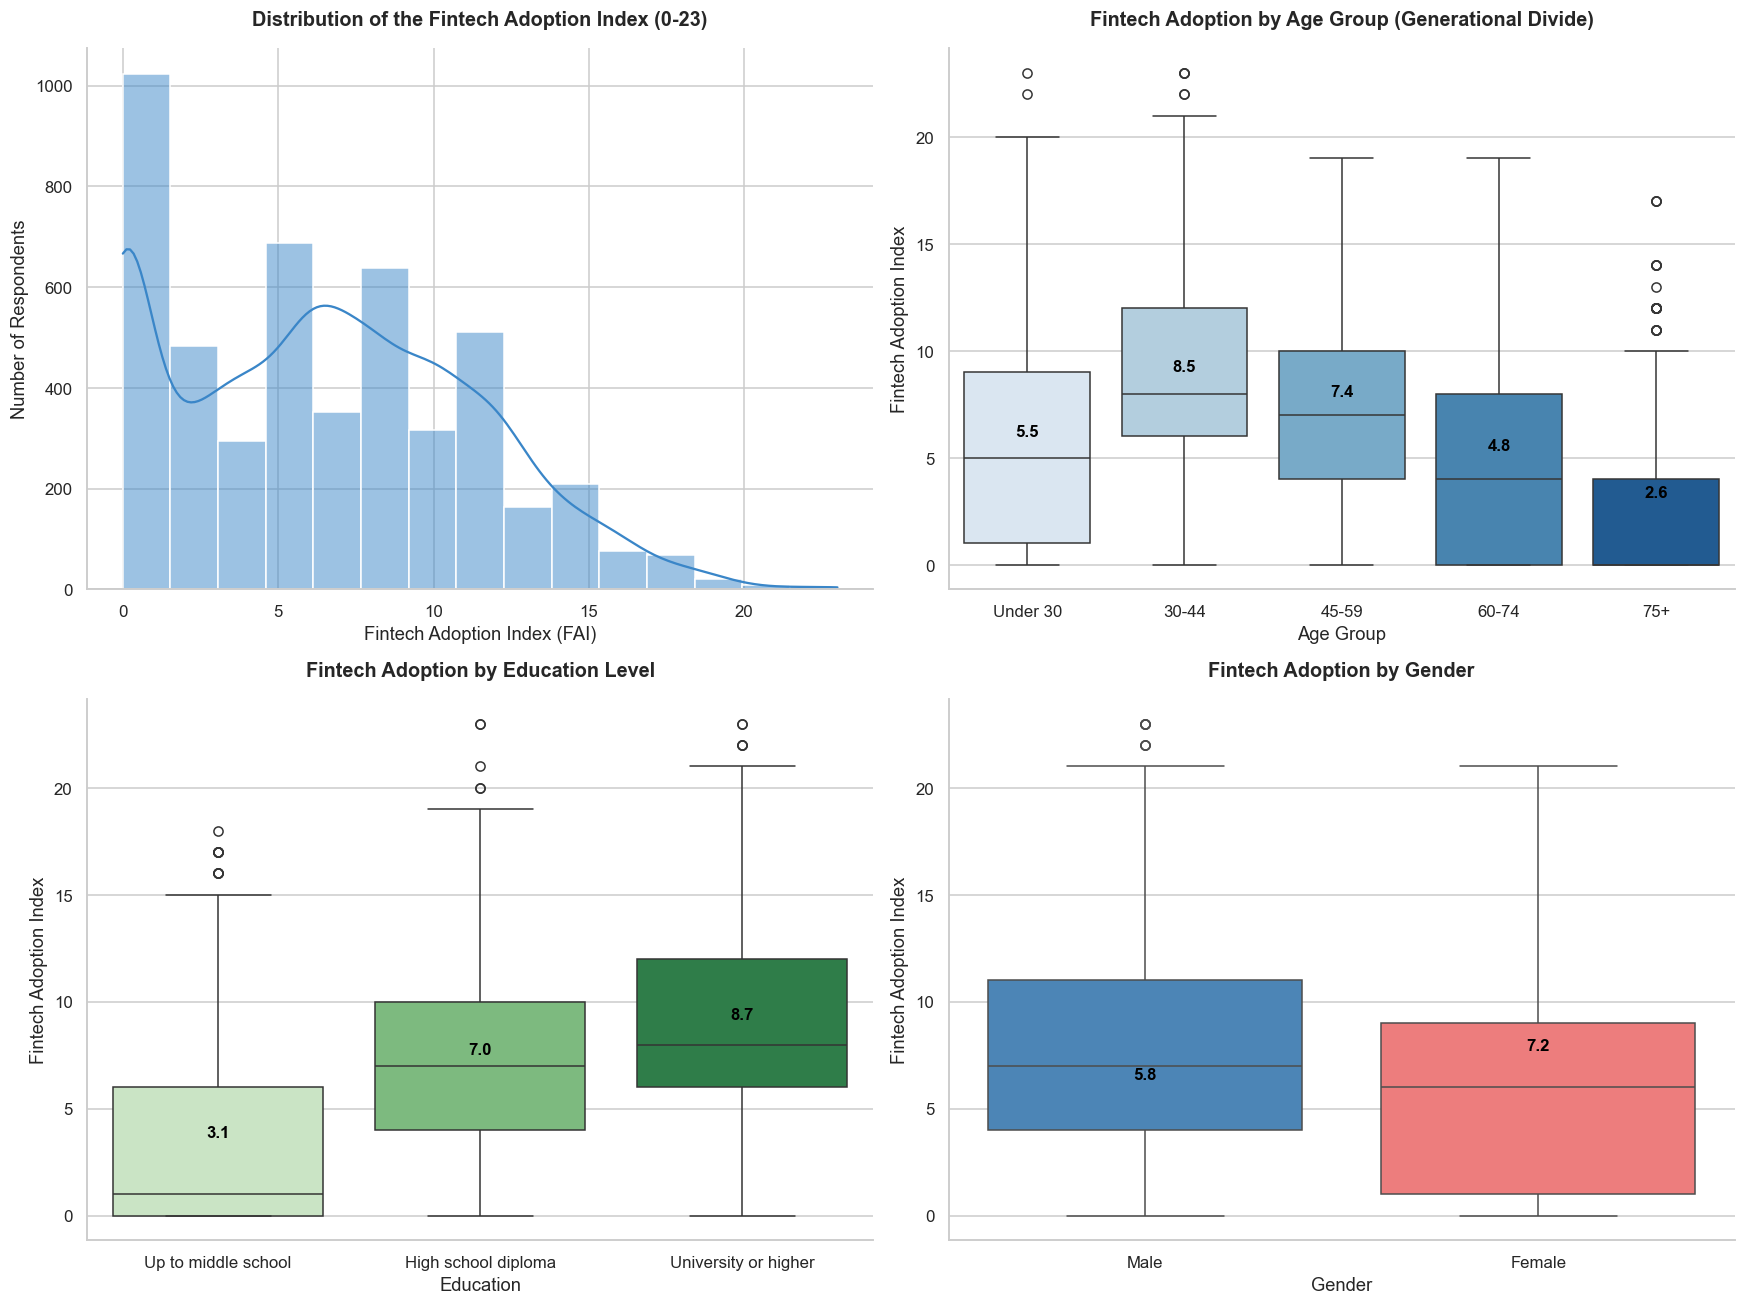

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall FAI Distribution
sns.histplot(data=df_clean, x='fintech_adoption', kde=True, color="#3A86C8", ax=axes[0, 0], bins=15)
axes[0, 0].set_title("Distribution of the Fintech Adoption Index (0-23)", fontsize=13)
axes[0, 0].set_xlabel("Fintech Adoption Index (FAI)")
axes[0, 0].set_ylabel("Number of Respondents")

# 2. Generational Divide (FAI by age group)
sns.boxplot(data=df_clean.dropna(subset=['age_class']), x='age_class', y='fintech_adoption', 
            palette="Blues", ax=axes[0, 1])
axes[0, 1].set_title("Fintech Adoption by Age Group (Generational Divide)", fontsize=13)
axes[0, 1].set_xlabel("Age Group")
axes[0, 1].set_ylabel("Fintech Adoption Index")

mean_age = df_clean.groupby('age_class', observed=False)['fintech_adoption'].mean()
for i, val in enumerate(mean_age):
    if not np.isnan(val):
        axes[0, 1].text(i, val + 0.4, f"{val:.1f}", ha='center', va='bottom', weight='bold', color='black')

# 3. Educational Divide (FAI by education level)
sns.boxplot(data=df_clean.dropna(subset=['education']), x='education', y='fintech_adoption', 
            palette="Greens", order=['Up to middle school', 'High school diploma', 'University or higher'], ax=axes[1, 0])
axes[1, 0].set_title("Fintech Adoption by Education Level", fontsize=13)
axes[1, 0].set_xlabel("Education")
axes[1, 0].set_ylabel("Fintech Adoption Index")

mean_edu = df_clean.groupby('education', observed=False)['fintech_adoption'].mean().reindex(['Up to middle school', 'High school diploma', 'University or higher'])
for i, val in enumerate(mean_edu):
    if not np.isnan(val):
        axes[1, 0].text(i, val + 0.4, f"{val:.1f}", ha='center', va='bottom', weight='bold', color='black')

# 4. Gender Gap (FAI by gender)
sns.boxplot(data=df_clean.dropna(subset=['gender']), x='gender', y='fintech_adoption', 
            palette=["#3A86C8", "#FF6B6B"], ax=axes[1, 1])
axes[1, 1].set_title("Fintech Adoption by Gender", fontsize=13)
axes[1, 1].set_xlabel("Gender")
axes[1, 1].set_ylabel("Fintech Adoption Index")

mean_gen = df_clean.groupby('gender')['fintech_adoption'].mean()
for i, val in enumerate(mean_gen):
    axes[1, 1].text(i, val + 0.4, f"{val:.1f}", ha='center', va='bottom', weight='bold', color='black')

plt.tight_layout()
plt.show()

## 5. Correlation Analysis and Bivariate Relationship

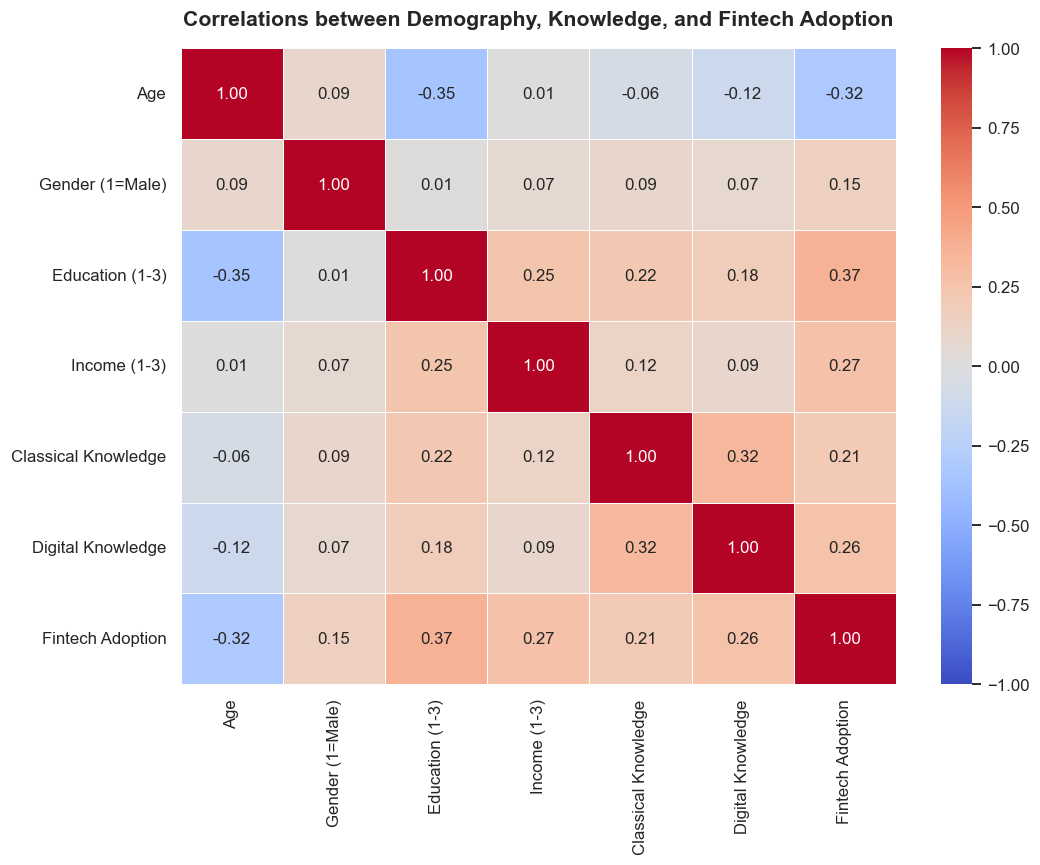

In [10]:
# Prepare a sub-dataframe with coded numerical variables for correlation
df_corr = pd.DataFrame()
df_corr['Age'] = df_clean['age']
df_corr['Gender (1=Male)'] = df['qd1']
df_corr['Education (1-3)'] = df_clean['qd9'].map({
    10: 1, 9: 1, 8: 1, 7: 1, 6: 1,  # Up to middle school
    5: 2, 4: 2,                     # Diploma
    3: 3, 2: 3, 1: 3                # University or higher
})
df_corr['Income (1-3)'] = df_clean['qd13'].map({1: 1, 2: 2, 3: 3})
df_corr['Classical Knowledge'] = df_clean['classical_knowledge']
df_corr['Digital Knowledge'] = df_clean['digital_knowledge']
df_corr['Fintech Adoption'] = df_clean['fintech_adoption']

# Matrix calculation
corr_matrix = df_corr.dropna().corr()

# Draw the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=.5)
plt.title("Correlations between Demography, Knowledge, and Fintech Adoption", fontsize=14, pad=15)
plt.tight_layout()
plt.show()